In [1]:
# ** This cell is needed since we are not in the src directory 
import sys 
import os
# Add the src/ directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src/")))

ROOT_DIR = ".."
SRC_DIR = ROOT_DIR + "/src"

import sys
sys.path.append("/Users/admin/eeg-ds004504/")


In [2]:
from config_handler import initiate_config, load_config

initiate_config()

{'data_path': '/Users/admin/eeg-ds004504',
 'derivatives': True,
 'freqBands': {'Alpha': [8, 12],
  'Beta': [12, 30],
  'Delta': [0.5, 4],
  'Theta': [4, 8],
  'custom1': [9, 11]},
 'method': 'welch',
 'stepSize': 0.3,
 'windowLength': 3}

In [3]:
print(load_config())

{'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 0.3, 'windowLength': 3}


In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import pandas_udf, PandasUDFType
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, ArrayType, MapType
import pandas as pd

In [5]:
# Check if there's an active Spark context and stop it
from pyspark import SparkContext
if SparkContext._active_spark_context:
    print("Stopping existing Spark context...")
    SparkContext._active_spark_context.stop()
    print("Previous Spark context stopped successfully")

In [6]:
# creating the ultimate most optimised spark session ever muwahaha
import os
from pyspark.sql import SparkSession

# Set Java options for the JVM running Spark
# -Xmx12g : Sets the maximum heap size to 12GB
# -Xms4g : Sets the initial heap size to 4GB to avoid resizing overhead
os.environ["_JAVA_OPTIONS"] = "-Xmx16g -Xms8g"

# Build Spark session with memory, parallelism, and network settings
spark = (
    SparkSession.builder 
    # Application name shown in Spark UI
    .appName("EEG_Analysis") 

    # SPARK DIRECTORY FOR THREADS / PERSIST
    
    # Use all available logical cores or specify a number
    # "local[*]" uses all available cores, "local[12]" limits to 12 threads
    .config("spark.master", "local[12]") \

    # Executor memory: how much memory each Spark worker can use
    .config("spark.executor.memory", "8g") \

    # Driver memory: memory available to the Spark driver (main Python process)
    .config("spark.driver.memory", "8g") \
    
    # THIS IS WHERE SPARK WILL PUT ITS TEMPERARY VARIABLES 
    # .config("spark.local.dir", os.path.expanduser("~/external-spark-tmp"))

    # Number of shuffle partitions (e.g., after groupBy, join, etc.)
    # Lower this in local mode to reduce overhead (default is 200)
    .config("spark.sql.shuffle.partitions", "12") \

    # Default number of partitions in operations like parallelize
    .config("spark.default.parallelism", "12") \

    # Maximum size (in MB) allowed for any RPC message (e.g., large UDF closures or data broadcasts)
    .config("spark.rpc.message.maxSize", "512") \

    # prevent breaking pipes 
    .config("spark.reducer.maxReqsInFlight", "1") \
    .config("spark.shuffle.io.preferDirectBufs", "false") \
    .config("spark.shuffle.file.buffer", "32k") \
    
    # Required for avoiding binding issues on some MacOS environments
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.host", "127.0.0.1") 
    .getOrCreate()
)

print("New Spark session created successfully")

Picked up _JAVA_OPTIONS: -Xmx16g -Xms8g
Picked up _JAVA_OPTIONS: -Xmx16g -Xms8g
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/24 23:05:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/04/24 23:05:45 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/04/24 23:05:45 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/04/24 23:05:45 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
25/04/24 23:05:45 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


New Spark session created successfully


In [7]:
for item in spark.sparkContext.getConf().getAll():
    print(item)


('spark.driver.extraJavaOptions', '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=java.base/sun.util.calendar=ALL-UNNAMED --add-opens=java.security.jgss/sun.security.krb5=ALL-UNNAMED -Djdk.reflect.useDirectMethodHandle=false')
('spark.default.parallelism', '12')
('spark.driver.host', '127.0.0.1')
('spark.app.submitTime', '1745550344

In [8]:
def reload_my_modules():
    import importlib
    import populate_schemas
    import feature_extraction
    import schema_definition
    importlib.reload(populate_schemas)
    importlib.reload(feature_extraction)
    importlib.reload(schema_definition)

reload_my_modules()


from populate_schemas import load_subjects_df, extract_features_udtf
from feature_extraction import processEpoch, processSub
from schema_definition import get_feature_schema, get_subject_schema

sc = spark.sparkContext # we pass udf/udtf's (user defind functions and user defined table functions) to spark so it can access them

# Making all necessary modules available to spark
try: 
    # oh btw spark is werid about not finding the config but it always finds it somehow not sure how that works not going to look rn tbh
    # ^ so feature_extraction has extra print statements
    sc.addPyFile(os.path.join(SRC_DIR, "feature_extraction.py"))
    print("Added feature_extraction.py to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "preprocess_sets.py"))
    print("Added preprocess_sets to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "schema_definition.py"))
    print("Added schema_definition.py to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "config_handler.py"))
    print("Added config_handler.py to the pyspark context")
except Exception as e:
    print(f"Error adding files to SparkContext: {e}")

Config not found in feature_extraction.py
Config using in feature Extraction.py {'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 0.3, 'windowLength': 3}
Config using in feature Extraction.py {'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 0.3, 'windowLength': 3}
Config using in feature Extraction.py {'data_path': '/Users/admin/eeg-ds004504', 'derivatives': True, 'freqBands': {'Alpha': [8, 12], 'Beta': [12, 30], 'Delta': [0.5, 4], 'Theta': [4, 8], 'custom1': [9, 11]}, 'method': 'welch', 'stepSize': 0.3, 'windowLength': 3}
Added feature_extraction.py to the pyspark context
Added preprocess_sets to the pyspark context
Added schema_definition.py to the pyspark context
Added config_handler

In [ ]:
%%time
alz_df_spark = spark.createDataFrame(alz_df_pandas)
cntrl_df_spark = spark.createDataFrame(cntrl_df_pandas)



In [10]:
%%time
alz_df_spark = spark.read.parquet("features_alz_extra_features_Apr19_2141.parquet")
cntrl_df_spark = spark.read.parquet("features_cntrl_extra_features_Apr19_2141.parquet")

CPU times: user 1.37 ms, sys: 1.34 ms, total: 2.71 ms
Wall time: 1.84 s


In [11]:
# alz_df_spark.parquet("spark_features_alz_extra_features_Apr19_2141.parquet")
# cntrl_df_spark.parquet("spark_features_cntrl_extra_features_Apr19_2141.parquet")

In [12]:
#just renaming things now that we understand the types and where things are coming from
alz_df = alz_df_spark
cntrl_df = cntrl_df_spark

In [13]:
alz_df.show()

+---------+-------+---------+--------+-----------+-------------+----------+
|SubjectID|EpochID|Electrode|WaveBand|FeatureName| FeatureValue|table_type|
+---------+-------+---------+--------+-----------+-------------+----------+
|  sub-008|   ep-0|      Fp1|   Alpha|      Power|  7.020328E-4|      band|
|  sub-008|   ep-0|      Fp1|    Beta|      Power|  3.399499E-4|      band|
|  sub-008|   ep-0|      Fp1|   Delta|      Power|  0.087231696|      band|
|  sub-008|   ep-0|      Fp1|   Theta|      Power| 0.0011391409|      band|
|  sub-008|   ep-0|      Fp1| custom1|      Power| 4.2795436E-4|      band|
|  sub-008|   ep-0|      Fp1|    NULL|TotalEnergy|   0.34805238| electrode|
|  sub-008|   ep-0|      Fp1|    NULL| TotalPower|  0.011235955| electrode|
|  sub-008|   ep-0|      Fp2|   Alpha|      Power| 0.0014689578|      band|
|  sub-008|   ep-0|      Fp2|    Beta|      Power|  5.043481E-4|      band|
|  sub-008|   ep-0|      Fp2|   Delta|      Power|   0.08462298|      band|
|  sub-008| 

# Start of data processing

In [14]:
# give each its respective labels
from pyspark.sql.functions import lit
alz_df = alz_df.withColumn("label", lit(1)).repartition(8).persist()
cntrl_df = cntrl_df.withColumn("label", lit(0)).repartition(8).persist()

In [15]:
# union everything
full_df = alz_df.unionByName(cntrl_df)

In [16]:
# Split based on feature type
from pyspark.sql.functions import col

band_df = full_df.filter(col("table_type") == "band")
channel_df = full_df.filter(col("table_type") == "electrode")
epoch_df = full_df.filter(col("table_type") == "epoch")


In [17]:
alz_df.unpersist()
cntrl_df.unpersist()

DataFrame[SubjectID: string, EpochID: string, Electrode: string, WaveBand: string, FeatureName: string, FeatureValue: float, table_type: string, label: int]

In [18]:
from pyspark.sql.functions import col

# Filter and save each to Parquet
full_df.filter(col("table_type") == "band") \
    .write.mode("overwrite").parquet("tempParquets/band_df")

full_df.filter(col("table_type") == "electrode") \
    .write.mode("overwrite").parquet("tempParquets/channel_df")

full_df.filter(col("table_type") == "epoch") \
    .write.mode("overwrite").parquet("tempParquets/epoch_df")

In [19]:
import os
os.system('say "START!"')

0

In [20]:
from pyspark.sql.functions import first
from pyspark.sql.functions import concat_ws


# Band-level: Electrode_WaveBand_Feature
band_df = band_df.withColumn("pivot", concat_ws("_", "Electrode", "WaveBand", "FeatureName")).repartition(1000, "SubjectID").persist()

# band_df.write.mode("overwrite").parquet("band_pre_pivot")
# Pivot band-level features
band_pivot = band_df.groupBy("SubjectID", "EpochID", "label").pivot("pivot").agg(first("FeatureValue"))
band_df.unpersist()

# Channel-level: Electrode_Feature
channel_df = channel_df.withColumn("pivot", concat_ws("_", "Electrode", "FeatureName")).repartition(1000, "SubjectID").persist()
# channel_df.write.mode("overwrite").parquet("channel_df_pre_pivot")

# Pivot channel-level features
channel_pivot = channel_df.groupBy("SubjectID", "EpochID", "label").pivot("pivot").agg(first("FeatureValue"))
channel_pivot.unpersist()


# Band-level: Electrode_WaveBand_Feature
epoch_df = epoch_df.withColumn("pivot", col("FeatureName")).repartition(1000, "SubjectID").persist()
# epoch_df.write.mode("overwrite").parquet("epoch_df_pre_pivot")


# Pivot epoch-level features
epoch_pivot = epoch_df.groupBy("SubjectID", "EpochID", "label").pivot("pivot").agg(first("FeatureValue"))
epoch_pivot.unpersist()

DataFrame[SubjectID: string, EpochID: string, label: int, AppEntropy: float, HiguchiFD: float, HjorthComplexity: float, HjorthMobility: float, KatzFD: float, Kurtosis: float, Mean: float, RMS: float, SampleEntropy: float, Skewness: float, Std: float, Variance: float]

In [54]:
import os
os.system('say "DONE!"')

0

In [22]:
from pyspark.sql.functions import first

# Pivot band-level features
band_pivot = band_df.groupBy("SubjectID", "EpochID", "label").pivot("pivot").agg(first("FeatureValue"))

# Pivot channel-level features
channel_pivot = channel_df.groupBy("SubjectID", "EpochID", "label").pivot("pivot").agg(first("FeatureValue"))

# Pivot epoch-level features
epoch_pivot = epoch_df.groupBy("SubjectID", "EpochID", "label").pivot("pivot").agg(first("FeatureValue"))

In [23]:
from functools import reduce

# full_df = reduce(
#     lambda df1, df2: df1.join(df2, on=["SubjectID", "EpochID", "label"], how="outer"),
#     [band_pivot, channel_pivot, epoch_pivot]
# ).fillna(0.0)


full_df = reduce(
    lambda df1, df2: df1.join(df2, on=["SubjectID", "EpochID", "label"], how="outer"),
     [band_pivot, channel_pivot, epoch_pivot]# band_pivot, channel_pivot, epoch_pivot]
).fillna(0.0)
full_df.repartition(16).persist()


25/04/24 23:17:13 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


DataFrame[SubjectID: string, EpochID: string, label: int, C3_Alpha_Power: float, C3_Beta_Power: float, C3_Delta_Power: float, C3_Theta_Power: float, C3_custom1_Power: float, C4_Alpha_Power: float, C4_Beta_Power: float, C4_Delta_Power: float, C4_Theta_Power: float, C4_custom1_Power: float, Cz_Alpha_Power: float, Cz_Beta_Power: float, Cz_Delta_Power: float, Cz_Theta_Power: float, Cz_custom1_Power: float, F3_Alpha_Power: float, F3_Beta_Power: float, F3_Delta_Power: float, F3_Theta_Power: float, F3_custom1_Power: float, F4_Alpha_Power: float, F4_Beta_Power: float, F4_Delta_Power: float, F4_Theta_Power: float, F4_custom1_Power: float, F7_Alpha_Power: float, F7_Beta_Power: float, F7_Delta_Power: float, F7_Theta_Power: float, F7_custom1_Power: float, F8_Alpha_Power: float, F8_Beta_Power: float, F8_Delta_Power: float, F8_Theta_Power: float, F8_custom1_Power: float, Fp1_Alpha_Power: float, Fp1_Beta_Power: float, Fp1_Delta_Power: float, Fp1_Theta_Power: float, Fp1_custom1_Power: float, Fp2_Alpha

In [24]:
band_pivot.unpersist()
channel_pivot.unpersist()
epoch_pivot.unpersist()

DataFrame[SubjectID: string, EpochID: string, label: int, AppEntropy: float, HiguchiFD: float, HjorthComplexity: float, HjorthMobility: float, KatzFD: float, Kurtosis: float, Mean: float, RMS: float, SampleEntropy: float, Skewness: float, Std: float, Variance: float]

In [25]:
type(full_df)

pyspark.sql.dataframe.DataFrame

In [26]:
full_df.repartition(16).persist()


25/04/24 23:17:13 WARN CacheManager: Asked to cache already cached data.


DataFrame[SubjectID: string, EpochID: string, label: int, C3_Alpha_Power: float, C3_Beta_Power: float, C3_Delta_Power: float, C3_Theta_Power: float, C3_custom1_Power: float, C4_Alpha_Power: float, C4_Beta_Power: float, C4_Delta_Power: float, C4_Theta_Power: float, C4_custom1_Power: float, Cz_Alpha_Power: float, Cz_Beta_Power: float, Cz_Delta_Power: float, Cz_Theta_Power: float, Cz_custom1_Power: float, F3_Alpha_Power: float, F3_Beta_Power: float, F3_Delta_Power: float, F3_Theta_Power: float, F3_custom1_Power: float, F4_Alpha_Power: float, F4_Beta_Power: float, F4_Delta_Power: float, F4_Theta_Power: float, F4_custom1_Power: float, F7_Alpha_Power: float, F7_Beta_Power: float, F7_Delta_Power: float, F7_Theta_Power: float, F7_custom1_Power: float, F8_Alpha_Power: float, F8_Beta_Power: float, F8_Delta_Power: float, F8_Theta_Power: float, F8_custom1_Power: float, Fp1_Alpha_Power: float, Fp1_Beta_Power: float, Fp1_Delta_Power: float, Fp1_Theta_Power: float, Fp1_custom1_Power: float, Fp2_Alpha

In [27]:
full_df.write.mode("overwrite").parquet("tempParquets/full_df")

                                                                                16]

# Reading the ttest/cohen results to do dimensionality reduction

In [29]:
results_df = pd.read_pickle("ttest+cohen_results_FILTERED.pkl")

In [30]:
results_df

,Feature,T_statistic,P_value,Cohen_d,Abs_Cohen_d
79,O2_Alpha_Power,3.703518e+02,0.0,-0.837593,0.837593
103,O2_custom1_Power,3.199367e+02,0.0,-0.789919,0.789919
91,T5_Alpha_Power,3.508133e+02,0.0,-0.776763,0.776763
93,O1_Alpha_Power,3.460411e+02,0.0,-0.745271,0.745271
117,T5_custom1_Power,3.020837e+02,0.0,-0.733409,0.733409
...,...,...,...,...,...
15,P4_TotalPower,1.768400e+18,0.0,0.000000,0.000000
16,C3_TotalPower,1.768400e+18,0.0,0.000000,0.000000
17,O1_TotalPower,1.768400e+18,0.0,0.000000,0.000000
18,F8_TotalPower,1.768400e+18,0.0,0.000000,0.000000


# Dimensionality reduction with t-test

In [31]:
results_df = pd.read_pickle("ttest+cohen_results.pkl")

In [32]:
cohen_min = 0.5
features_of_interest = results_df[results_df["Abs_Cohen_d"] > cohen_min]["Feature"].tolist()

In [33]:
print(f"After cohen test we have {len( features_of_interest)} features of interest with a cohen value greater then {cohen_min}")
print(features_of_interest)

After cohen test we have 15 features of interest with a cohen value greater then 0.5
['O2_Alpha_Power', 'O2_custom1_Power', 'T5_Alpha_Power', 'O1_Alpha_Power', 'T5_custom1_Power', 'O1_custom1_Power', 'T6_Alpha_Power', 'T6_custom1_Power', 'O2_Delta_Power', 'P3_custom1_Power', 'P3_Alpha_Power', 'Pz_custom1_Power', 'Pz_Alpha_Power', 'T5_Delta_Power', 'O1_Delta_Power']


In [34]:
# Required columns to retain
meta_cols = ["label", "SubjectID", "EpochID"]  # add/remove as needed
selected_cols = meta_cols + features_of_interest
features_of_interest


['O2_Alpha_Power',
 'O2_custom1_Power',
 'T5_Alpha_Power',
 'O1_Alpha_Power',
 'T5_custom1_Power',
 'O1_custom1_Power',
 'T6_Alpha_Power',
 'T6_custom1_Power',
 'O2_Delta_Power',
 'P3_custom1_Power',
 'P3_Alpha_Power',
 'Pz_custom1_Power',
 'Pz_Alpha_Power',
 'T5_Delta_Power',
 'O1_Delta_Power']

In [35]:
full_df.head(1)

                                                                                16]

[Row(SubjectID='sub-001', EpochID='ep-0', label=1, C3_Alpha_Power=0.0015840474516153336, C3_Beta_Power=0.00032858349732123315, C3_Delta_Power=0.08289602398872375, C3_Theta_Power=0.0042826407589018345, C3_custom1_Power=0.0014919989043846726, C4_Alpha_Power=0.0012796665541827679, C4_Beta_Power=0.0002907446469180286, C4_Delta_Power=0.08419696241617203, C4_Theta_Power=0.0035647668410092592, C4_custom1_Power=0.0010057570179924369, Cz_Alpha_Power=0.0014217610005289316, Cz_Beta_Power=0.00028325579478405416, Cz_Delta_Power=0.08330944180488586, Cz_Theta_Power=0.004269932862371206, Cz_custom1_Power=0.001263527781702578, F3_Alpha_Power=0.001112336409278214, F3_Beta_Power=0.00029922040994279087, F3_Delta_Power=0.08212275058031082, F3_Theta_Power=0.005595318973064423, F3_custom1_Power=0.0010602525435388088, F4_Alpha_Power=0.0012141390470787883, F4_Beta_Power=0.0003739811363629997, F4_Delta_Power=0.0829239934682846, F4_Theta_Power=0.004422619938850403, F4_custom1_Power=0.0009742741822265089, F7_Alph

In [36]:
full_df = full_df.select(*selected_cols)

In [37]:
full_df.head(1)

                                                                                ]

[Row(label=1, SubjectID='sub-001', EpochID='ep-0', O2_Alpha_Power=0.0016899789916351438, O2_custom1_Power=0.0014481887919828296, T5_Alpha_Power=0.0020100425463169813, O1_Alpha_Power=0.0019374857656657696, T5_custom1_Power=0.0021589354146271944, O1_custom1_Power=0.001973925856873393, T6_Alpha_Power=0.0011663214536383748, T6_custom1_Power=0.0010646645678207278, O2_Delta_Power=0.08369071036577225, P3_custom1_Power=0.001460108207538724, P3_Alpha_Power=0.0016621516551822424, Pz_custom1_Power=0.0012268444988876581, Pz_Alpha_Power=0.0015581639017909765, T5_Delta_Power=0.08303152769804001, O1_Delta_Power=0.08236794173717499)]

In [38]:
len(full_df.head(1)[0])

                                                                                ]

18

In [39]:
# Min maxing accross everything

In [40]:
from pyspark.sql.functions import min as spark_min, max as spark_max

# Example list of selected features (from Cohen's d filtering)
# You already have: features_of_interest
stat_exprs = []

for feature in features_of_interest:
    stat_exprs.append(spark_min(feature).alias(f"{feature}_min"))
    stat_exprs.append(spark_max(feature).alias(f"{feature}_max"))

# Compute min and max for all selected features
feature_ranges = full_df.select(*features_of_interest).agg(*stat_exprs)



# we need to try z-score, z-score by subjet, min_max, min_max by subject

In [41]:
from pyspark.sql.functions import col, lit

feature_ranges_row = feature_ranges.collect()[0].asDict()

for feat in features_of_interest:
    min_val = feature_ranges_row[f"{feat}_min"]
    max_val = feature_ranges_row[f"{feat}_max"]
    denom = max_val - min_val if max_val != min_val else 1.0  # avoid divide-by-zero

    # Overwrite the original column
    train_df = full_df.withColumn(
        feat,
        (2 * (col(feat) - lit(min_val)) / lit(denom)) - 1
    )

    test_df = full_df.withColumn(
        feat,
        (2 * (col(feat) - lit(min_val)) / lit(denom)) - 1
    )


                                                                                ]

In [42]:
full_df.head(1)

                                                                                ]

[Row(label=1, SubjectID='sub-001', EpochID='ep-0', O2_Alpha_Power=0.0016899789916351438, O2_custom1_Power=0.0014481887919828296, T5_Alpha_Power=0.0020100425463169813, O1_Alpha_Power=0.0019374857656657696, T5_custom1_Power=0.0021589354146271944, O1_custom1_Power=0.001973925856873393, T6_Alpha_Power=0.0011663214536383748, T6_custom1_Power=0.0010646645678207278, O2_Delta_Power=0.08369071036577225, P3_custom1_Power=0.001460108207538724, P3_Alpha_Power=0.0016621516551822424, Pz_custom1_Power=0.0012268444988876581, Pz_Alpha_Power=0.0015581639017909765, T5_Delta_Power=0.08303152769804001, O1_Delta_Power=0.08236794173717499)]

In [43]:
from pyspark.sql.functions import min as spark_min, max as spark_max

# Example list of selected features (from Cohen's d filtering)
# You already have: features_of_interest
stat_exprs = []

for feature in features_of_interest:
    stat_exprs.append(spark_min(feature).alias(f"{feature}_min"))
    stat_exprs.append(spark_max(feature).alias(f"{feature}_max"))

# Compute min and max for all selected features
feature_ranges = train_df.select(*features_of_interest).agg(*stat_exprs)

In [44]:
full_df.head(1)

                                                                                ]

[Row(label=1, SubjectID='sub-001', EpochID='ep-0', O2_Alpha_Power=0.0016899789916351438, O2_custom1_Power=0.0014481887919828296, T5_Alpha_Power=0.0020100425463169813, O1_Alpha_Power=0.0019374857656657696, T5_custom1_Power=0.0021589354146271944, O1_custom1_Power=0.001973925856873393, T6_Alpha_Power=0.0011663214536383748, T6_custom1_Power=0.0010646645678207278, O2_Delta_Power=0.08369071036577225, P3_custom1_Power=0.001460108207538724, P3_Alpha_Power=0.0016621516551822424, Pz_custom1_Power=0.0012268444988876581, Pz_Alpha_Power=0.0015581639017909765, T5_Delta_Power=0.08303152769804001, O1_Delta_Power=0.08236794173717499)]

In [45]:
print("got here")

got here


# ML time

In [46]:
full_df.columns

['label',
 'SubjectID',
 'EpochID',
 'O2_Alpha_Power',
 'O2_custom1_Power',
 'T5_Alpha_Power',
 'O1_Alpha_Power',
 'T5_custom1_Power',
 'O1_custom1_Power',
 'T6_Alpha_Power',
 'T6_custom1_Power',
 'O2_Delta_Power',
 'P3_custom1_Power',
 'P3_Alpha_Power',
 'Pz_custom1_Power',
 'Pz_Alpha_Power',
 'T5_Delta_Power',
 'O1_Delta_Power']

In [47]:
full_df.orderBy(["SubjectID", "label"])
full_df.head(1)

                                                                                ]

[Row(label=1, SubjectID='sub-001', EpochID='ep-0', O2_Alpha_Power=0.0016899789916351438, O2_custom1_Power=0.0014481887919828296, T5_Alpha_Power=0.0020100425463169813, O1_Alpha_Power=0.0019374857656657696, T5_custom1_Power=0.0021589354146271944, O1_custom1_Power=0.001973925856873393, T6_Alpha_Power=0.0011663214536383748, T6_custom1_Power=0.0010646645678207278, O2_Delta_Power=0.08369071036577225, P3_custom1_Power=0.001460108207538724, P3_Alpha_Power=0.0016621516551822424, Pz_custom1_Power=0.0012268444988876581, Pz_Alpha_Power=0.0015581639017909765, T5_Delta_Power=0.08303152769804001, O1_Delta_Power=0.08236794173717499)]

In [48]:
# Get unique subject list for Alzheimer's (label = 1)
alz_sub_list = (
    train_df.filter(train_df.label == 1)
    .select("SubjectID")
    .distinct()
    .rdd.flatMap(lambda x: x)
    .collect()
)

# Get unique subject list for Control (label = 0)
cntrl_sub_list = (
    train_df.filter(train_df.label == 0)
    .select("SubjectID")
    .distinct()
    .rdd.flatMap(lambda x: x)
    .collect()
)

                                                                                ]

In [49]:
cntrl_sub_list.sort()
alz_sub_list.sort()

print(alz_sub_list)
print(len(alz_sub_list))
print(cntrl_sub_list)
print(len(cntrl_sub_list))

['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-020', 'sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-025', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030', 'sub-031', 'sub-032', 'sub-033', 'sub-034', 'sub-035', 'sub-036']
36
['sub-037', 'sub-038', 'sub-039', 'sub-040', 'sub-041', 'sub-042', 'sub-043', 'sub-044', 'sub-045', 'sub-046', 'sub-047', 'sub-048', 'sub-049', 'sub-050', 'sub-051', 'sub-052', 'sub-053', 'sub-054', 'sub-055', 'sub-056', 'sub-057', 'sub-058', 'sub-059', 'sub-060', 'sub-061', 'sub-062', 'sub-063', 'sub-064', 'sub-065']
29


In [50]:
full_df = full_df.toPandas()

                                                                                ]

In [51]:
full_df.columns.tolist()

['label',
 'SubjectID',
 'EpochID',
 'O2_Alpha_Power',
 'O2_custom1_Power',
 'T5_Alpha_Power',
 'O1_Alpha_Power',
 'T5_custom1_Power',
 'O1_custom1_Power',
 'T6_Alpha_Power',
 'T6_custom1_Power',
 'O2_Delta_Power',
 'P3_custom1_Power',
 'P3_Alpha_Power',
 'Pz_custom1_Power',
 'Pz_Alpha_Power',
 'T5_Delta_Power',
 'O1_Delta_Power']

In [52]:
full_df.columns.tolist()

['label',
 'SubjectID',
 'EpochID',
 'O2_Alpha_Power',
 'O2_custom1_Power',
 'T5_Alpha_Power',
 'O1_Alpha_Power',
 'T5_custom1_Power',
 'O1_custom1_Power',
 'T6_Alpha_Power',
 'T6_custom1_Power',
 'O2_Delta_Power',
 'P3_custom1_Power',
 'P3_Alpha_Power',
 'Pz_custom1_Power',
 'Pz_Alpha_Power',
 'T5_Delta_Power',
 'O1_Delta_Power']

In [53]:
type(full_df)

pandas.core.frame.DataFrame

In [57]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from joblib import Parallel, delayed
import pandas as pd

# Setup
target_names = ["Control", "Alzheimer's"]
exclude_cols = ["label", "SubjectID", "EpochID"]
feature_cols = [col for col in full_df.columns if col not in exclude_cols]

def evaluate_subject(test_subject):
    print(f"\n🔄 Evaluating: {test_subject}")
    
    model = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        alpha=1e-6,
        early_stopping=True,
        max_iter=30000,
        random_state=42
    )
    
    train_pd = full_df[full_df["SubjectID"] != test_subject]
    test_pd = full_df[full_df["SubjectID"] == test_subject]

    X_train = train_pd[feature_cols].values
    y_train = train_pd["label"].values
    X_test = test_pd[feature_cols].values
    y_test = test_pd["label"].values

    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    # Get label info for classification report
    test_label_val = y_test[0]
    test_label_name = target_names[test_label_val]

    print(f"✅ {test_subject} - Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")
    
    print(classification_report(
        y_test,
        y_pred_test,
        labels=[test_label_val],
        target_names=[test_label_name],
        zero_division=0
    ))
    
    return test_subject, list(y_pred_test == y_test)

# Parallel execution
results = Parallel(n_jobs=-1)(delayed(evaluate_subject)(subj) for subj in alz_sub_list)

# Convert to DataFrame
alz_pred_correct_df = pd.DataFrame.from_dict(dict(results), orient="index")
alz_pred_correct_df.index.name = "SubjectID"

print("\n✅ Prediction correctness matrix (True = correct, False = wrong):")
print(alz_pred_correct_df.head())



✅ Prediction correctness matrix (True = correct, False = wrong):
           0      1      2      3      4      5      6     7      8      9     \
SubjectID                                                                       
sub-001    True   True   True   True   True   True   True  True   True   True   
sub-002    True  False  False  False  False  False   True  True  False  False   
sub-003    True  False  False   True   True  False  False  True  False   True   
sub-004    True   True   True  False   True   True   True  True   True   True   
sub-005    True  False   True   True   True   True   True  True   True   True   

           ...  4284  4285  4286  4287  4288  4289  4290  4291  4292  4293  
SubjectID  ...                                                              
sub-001    ...  None  None  None  None  None  None  None  None  None  None  
sub-002    ...  None  None  None  None  None  None  None  None  None  None  
sub-003    ...  None  None  None  None  None  None  None  

In [59]:
# Calculate accuracy per subject (skip NaNs/None automatically)
subject_accuracies = alz_pred_correct_df.mean(axis=1)

# Get subjects with accuracy > 0.5
subjects_above_50 = subject_accuracies[subject_accuracies > 0.5].index.tolist()
subjects_below_50 = subject_accuracies[subject_accuracies <= 0.5].index.tolist()


print("Subjects where model was correct by half the time:")
print(subjects_above_50)
print("Subjects where model was incorrect by half the time:")
print(subjects_below_50)
print(f"✅ Overall accuracy: {len(subjects_above_50)}/{len(subjects_above_50) + len(subjects_below_50)}")

Subjects where model was correct by half the time:
['sub-001', 'sub-002', 'sub-004', 'sub-005', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-020', 'sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030', 'sub-032', 'sub-033', 'sub-034', 'sub-035', 'sub-036']
Subjects where model was incorrect by half the time:
['sub-003', 'sub-006', 'sub-011', 'sub-025', 'sub-031']
✅ Overall accuracy: 31/36


In [60]:
results = Parallel(n_jobs=-1)(delayed(evaluate_subject)(subj) for subj in cntrl_sub_list)

# Convert to DataFrame
cntrl_pred_correct_df = pd.DataFrame.from_dict(dict(results), orient="index")
cntrl_pred_correct_df.index.name = "SubjectID"

print("\n✅ Prediction correctness matrix (True = correct, False = wrong):")
print(cntrl_pred_correct_df.head())


✅ Prediction correctness matrix (True = correct, False = wrong):
            0      1      2      3      4      5      6     7      8     \
SubjectID                                                                 
sub-037     True   True  False  False   True   True   True  True  False   
sub-038    False   True   True   True   True   True   True  True  False   
sub-039     True   True   True   True   True   True  False  True   True   
sub-040     True   True   True   True  False  False  False  True   True   
sub-041    False  False  False   True  False   True   True  True   True   

            9     ...  3371  3372  3373   3374   3375  3376  3377   3378  \
SubjectID         ...                                                      
sub-037     True  ...  None  None  None   None   None  None  None   None   
sub-038     True  ...  None  None  None   None   None  None  None   None   
sub-039     True  ...  None  None  None   None   None  None  None   None   
sub-040     True  ...  True 

In [61]:
# Calculate accuracy per subject (skip NaNs/None automatically)
subject_accuracies = cntrl_pred_correct_df.mean(axis=1)

# Get subjects with accuracy > 0.5
subjects_above_50 = subject_accuracies[subject_accuracies > 0.5].index.tolist()
subjects_below_50 = subject_accuracies[subject_accuracies <= 0.5].index.tolist()


print("Subjects where model was correct by half the time:")
print(subjects_above_50)
print("Subjects where model was incorrect by half the time:")
print(subjects_below_50)
print(f"✅ Overall accuracy: {len(subjects_above_50)}/{len(subjects_above_50) + len(subjects_below_50)}")

Subjects where model was correct by half the time:
['sub-038', 'sub-039', 'sub-040', 'sub-042', 'sub-044', 'sub-046', 'sub-047', 'sub-048', 'sub-049', 'sub-052', 'sub-053', 'sub-054', 'sub-055', 'sub-057', 'sub-062', 'sub-064', 'sub-065']
Subjects where model was incorrect by half the time:
['sub-037', 'sub-041', 'sub-043', 'sub-045', 'sub-050', 'sub-051', 'sub-056', 'sub-058', 'sub-059', 'sub-060', 'sub-061', 'sub-063']
✅ Overall accuracy: 17/29


In [62]:
17+32

49

In [63]:
36+29

65


🔄 Evaluating: sub-040
✅ sub-040 - Train Acc: 0.7720, Test Acc: 0.6681
              precision    recall  f1-score   support

     Control       1.00      0.67      0.80      3381

   micro avg       1.00      0.67      0.80      3381
   macro avg       1.00      0.67      0.80      3381
weighted avg       1.00      0.67      0.80      3381


🔄 Evaluating: sub-047
✅ sub-047 - Train Acc: 0.7694, Test Acc: 0.7403
              precision    recall  f1-score   support

     Control       1.00      0.74      0.85      2684

   micro avg       1.00      0.74      0.85      2684
   macro avg       1.00      0.74      0.85      2684
weighted avg       1.00      0.74      0.85      2684


🔄 Evaluating: sub-056
✅ sub-056 - Train Acc: 0.7907, Test Acc: 0.4290
              precision    recall  f1-score   support

     Control       1.00      0.43      0.60      2942

   micro avg       1.00      0.43      0.60      2942
   macro avg       1.00      0.43      0.60      2942
weighted avg       1.00

In [70]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

def evaluate_subject_gbc_with_cv(test_subject, group_name):
    model = GradientBoostingClassifier(n_estimators=100, random_state=42)

    train_pd = full_df[full_df["SubjectID"] != test_subject]
    test_pd = full_df[full_df["SubjectID"] == test_subject]

    X_train = train_pd[feature_cols].values
    y_train = train_pd["label"].values
    X_test = test_pd[feature_cols].values
    y_test = test_pd["label"].values

    # 5-fold cross-validation on training data
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=1)

    print(f"\n🔁 Cross-validation (train set) accuracy for {test_subject}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Train model on full training set
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)

    test_acc = accuracy_score(y_test, y_pred_test)
    test_label_val = y_test[0]
    test_label_name = target_names[test_label_val]

    print(f"✅ [{group_name}] {test_subject} - Test Acc: {test_acc:.4f}")
    print(classification_report(
        y_test,
        y_pred_test,
        labels=[test_label_val],
        target_names=[test_label_name],
        zero_division=0
    ))

    return test_subject, list(y_pred_test == y_test)


In [71]:
# Run for Alzheimer's subjects
alz_results = Parallel(n_jobs=-1)(
    delayed(evaluate_subject_gbc_with_cv)(subj, "Alzheimer's") for subj in alz_sub_list
)
print("done")

✅ [Control] sub-040 - Test Acc: 0.6684
              precision    recall  f1-score   support

     Control       1.00      0.67      0.80      3381

   micro avg       1.00      0.67      0.80      3381
   macro avg       1.00      0.67      0.80      3381
weighted avg       1.00      0.67      0.80      3381

✅ [Control] sub-047 - Test Acc: 0.7843
              precision    recall  f1-score   support

     Control       1.00      0.78      0.88      2684

   micro avg       1.00      0.78      0.88      2684
   macro avg       1.00      0.78      0.88      2684
weighted avg       1.00      0.78      0.88      2684

✅ [Control] sub-057 - Test Acc: 0.9395
              precision    recall  f1-score   support

     Control       1.00      0.94      0.97      2645

   micro avg       1.00      0.94      0.97      2645
   macro avg       1.00      0.94      0.97      2645
weighted avg       1.00      0.94      0.97      2645


🔁 Cross-validation (train set) accuracy for sub-008: 0.7430 ± 0

In [72]:
# Run for Control subjects
cntrl_results = Parallel(n_jobs=-1)(
    delayed(evaluate_subject_gbc_with_cv)(subj, "Control") for subj in cntrl_sub_list
)
print("done")

✅ [Control] sub-037 - Test Acc: 0.4653
              precision    recall  f1-score   support

     Control       1.00      0.47      0.64      2581

   micro avg       1.00      0.47      0.64      2581
   macro avg       1.00      0.47      0.64      2581
weighted avg       1.00      0.47      0.64      2581

✅ [Control] sub-055 - Test Acc: 0.6054
              precision    recall  f1-score   support

     Control       1.00      0.61      0.75      2737

   micro avg       1.00      0.61      0.75      2737
   macro avg       1.00      0.61      0.75      2737
weighted avg       1.00      0.61      0.75      2737

✅ [Control] sub-064 - Test Acc: 0.9500
              precision    recall  f1-score   support

     Control       1.00      0.95      0.97      2821

   micro avg       1.00      0.95      0.97      2821
   macro avg       1.00      0.95      0.97      2821
weighted avg       1.00      0.95      0.97      2821


🔁 Cross-validation (train set) accuracy for sub-006: 0.7494 ± 0

In [73]:
# Convert to DataFrames
alz_pred_correct_df = pd.DataFrame.from_dict(dict(alz_results), orient="index")
cntrl_pred_correct_df = pd.DataFrame.from_dict(dict(cntrl_results), orient="index")

alz_pred_correct_df.index.name = "SubjectID"
cntrl_pred_correct_df.index.name = "SubjectID"

# Analyze subject-level accuracies
alz_accuracies = alz_pred_correct_df.mean(axis=1)
alz_above_50 = alz_accuracies[alz_accuracies > 0.5].index.tolist()
alz_below_50 = alz_accuracies[alz_accuracies <= 0.5].index.tolist()

cntrl_accuracies = cntrl_pred_correct_df.mean(axis=1)
cntrl_above_50 = cntrl_accuracies[cntrl_accuracies > 0.5].index.tolist()
cntrl_below_50 = cntrl_accuracies[cntrl_accuracies <= 0.5].index.tolist()

# Print summaries
print("\n✅ Alzheimer’s Summary")
print("Subjects >50% Accuracy:", alz_above_50)
print("Subjects <=50% Accuracy:", alz_below_50)
print(f"✅ Overall: {len(alz_above_50)}/{len(alz_above_50 + alz_below_50)}")

print("\n✅ Control Summary")
print("Subjects >50% Accuracy:", cntrl_above_50)
print("Subjects <=50% Accuracy:", cntrl_below_50)
print(f"✅ Overall: {len(cntrl_above_50)}/{len(cntrl_above_50 + cntrl_below_50)}")


✅ Alzheimer’s Summary
Subjects >50% Accuracy: ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-017', 'sub-018', 'sub-019', 'sub-020', 'sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030', 'sub-032', 'sub-033', 'sub-034', 'sub-035', 'sub-036']
Subjects <=50% Accuracy: ['sub-006', 'sub-011', 'sub-025', 'sub-031']
✅ Overall: 32/36

✅ Control Summary
Subjects >50% Accuracy: ['sub-038', 'sub-039', 'sub-040', 'sub-042', 'sub-044', 'sub-046', 'sub-047', 'sub-048', 'sub-049', 'sub-052', 'sub-053', 'sub-054', 'sub-055', 'sub-057', 'sub-062', 'sub-064']
Subjects <=50% Accuracy: ['sub-037', 'sub-041', 'sub-043', 'sub-045', 'sub-050', 'sub-051', 'sub-056', 'sub-058', 'sub-059', 'sub-060', 'sub-061', 'sub-063', 'sub-065']
✅ Overall: 16/29


In [74]:
def summarize_subject_accuracies(pred_df, group_name):
    summary = []

    for subject_id in pred_df.index:
        per_epoch_correct = pred_df.loc[subject_id].dropna().values
        total = len(per_epoch_correct)
        correct = sum(per_epoch_correct)
        acc = correct / total if total > 0 else 0

        summary.append({
            "SubjectID": subject_id,
            "Group": group_name,
            "Test Accuracy": round(acc, 4),
            "Correct": correct,
            "Total Epochs": total
        })

    return pd.DataFrame(summary)


In [76]:
alz_summary_df = summarize_subject_accuracies(alz_pred_correct_df, "Alzheimer's")
cntrl_summary_df = summarize_subject_accuracies(cntrl_pred_correct_df, "Control")
print(alz_summary_df.head())
print(cntrl_summary_df.head())


  SubjectID        Group  Test Accuracy  Correct  Total Epochs
0   sub-001  Alzheimer's         0.9975     1985          1990
1   sub-002  Alzheimer's         0.6177     1627          2634
2   sub-003  Alzheimer's         0.5690      577          1014
3   sub-004  Alzheimer's         0.9996     2346          2347
4   sub-005  Alzheimer's         0.9764     2608          2671
  SubjectID    Group  Test Accuracy  Correct  Total Epochs
0   sub-037  Control         0.4653     1201          2581
1   sub-038  Control         0.7277     2162          2971
2   sub-039  Control         0.7165     2040          2847
3   sub-040  Control         0.6684     2260          3381
4   sub-041  Control         0.3241      955          2947


In [80]:
print(alz_summary_df.sort_values(by="Test Accuracy", ascending=False))


   SubjectID        Group  Test Accuracy  Correct  Total Epochs
15   sub-016  Alzheimer's         0.9997     3273          3274
3    sub-004  Alzheimer's         0.9996     2346          2347
0    sub-001  Alzheimer's         0.9975     1985          1990
34   sub-035  Alzheimer's         0.9964     2505          2514
6    sub-007  Alzheimer's         0.9930     2536          2554
27   sub-028  Alzheimer's         0.9898     2717          2745
28   sub-029  Alzheimer's         0.9866     2426          2459
13   sub-014  Alzheimer's         0.9841     3091          3141
20   sub-021  Alzheimer's         0.9840     3019          3068
26   sub-027  Alzheimer's         0.9830     2713          2760
7    sub-008  Alzheimer's         0.9830     2609          2654
25   sub-026  Alzheimer's         0.9800     2987          3048
23   sub-024  Alzheimer's         0.9800     2498          2549
4    sub-005  Alzheimer's         0.9764     2608          2671
33   sub-034  Alzheimer's         0.9712

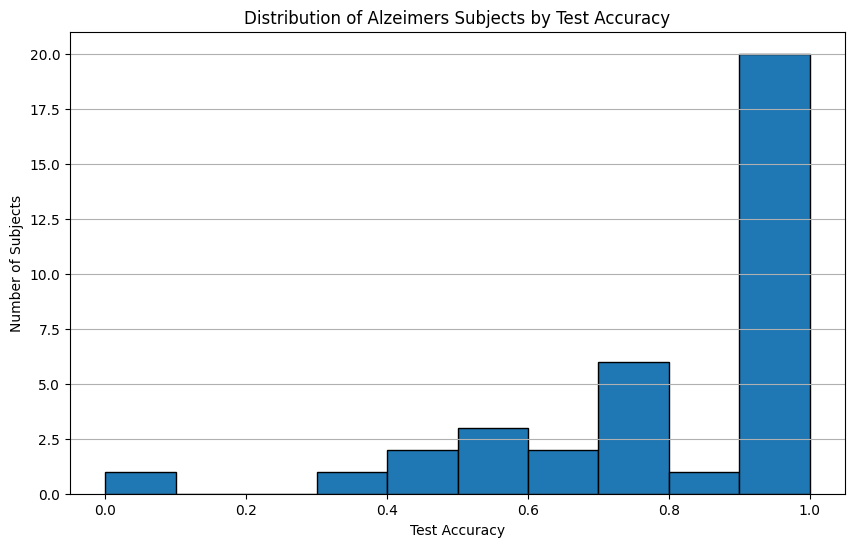

In [88]:
import matplotlib.pyplot as plt
import numpy as np
# Assuming alz_summary_df already exists
# (if not, generate it from your prediction correctness data)

# Sort the DataFrame (optional, not strictly needed for histogram)
alz_summary_df_sorted = alz_summary_df.sort_values(by="Test Accuracy", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.hist(alz_summary_df_sorted["Test Accuracy"], bins=np.linspace(0, 1, 11), edgecolor='black')
plt.title("Distribution of Alzeimers Subjects by Test Accuracy")
plt.xlabel("Test Accuracy")
plt.ylabel("Number of Subjects")
plt.grid(axis='y')
plt.ylim(0,21)

plt.show()


In [81]:
print(cntrl_summary_df.sort_values(by="Test Accuracy", ascending=False))


   SubjectID    Group  Test Accuracy  Correct  Total Epochs
27   sub-064  Control         0.9500     2680          2821
17   sub-054  Control         0.9407     2632          2798
20   sub-057  Control         0.9395     2485          2645
12   sub-049  Control         0.9009     2346          2604
25   sub-062  Control         0.8858     2685          3031
5    sub-042  Control         0.8794     2850          3241
11   sub-048  Control         0.8465     2851          3368
10   sub-047  Control         0.7843     2105          2684
7    sub-044  Control         0.7822     2291          2929
1    sub-038  Control         0.7277     2162          2971
2    sub-039  Control         0.7165     2040          2847
3    sub-040  Control         0.6684     2260          3381
16   sub-053  Control         0.6573     1745          2655
9    sub-046  Control         0.6386     1608          2518
18   sub-055  Control         0.6054     1657          2737
15   sub-052  Control         0.5584    

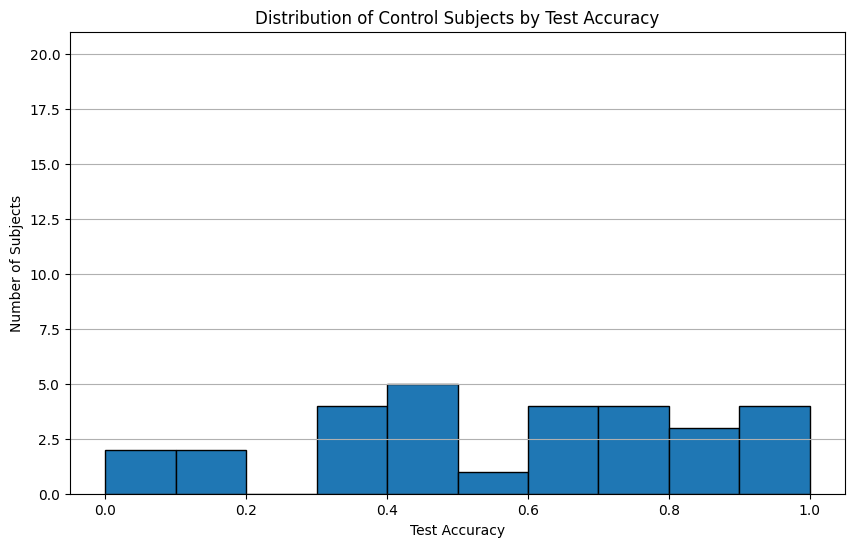

In [89]:
import matplotlib.pyplot as plt
import numpy as np
# Assuming alz_summary_df already exists
# (if not, generate it from your prediction correctness data)

# Sort the DataFrame (optional, not strictly needed for histogram)
cntrl_summary_df_sorted = cntrl_summary_df.sort_values(by="Test Accuracy", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.hist(cntrl_summary_df_sorted["Test Accuracy"], bins=np.linspace(0, 1, 11), edgecolor='black')
plt.title("Distribution of Control Subjects by Test Accuracy")
plt.xlabel("Test Accuracy")
plt.ylabel("Number of Subjects")
plt.grid(axis='y')
plt.ylim(0,21)
plt.show()


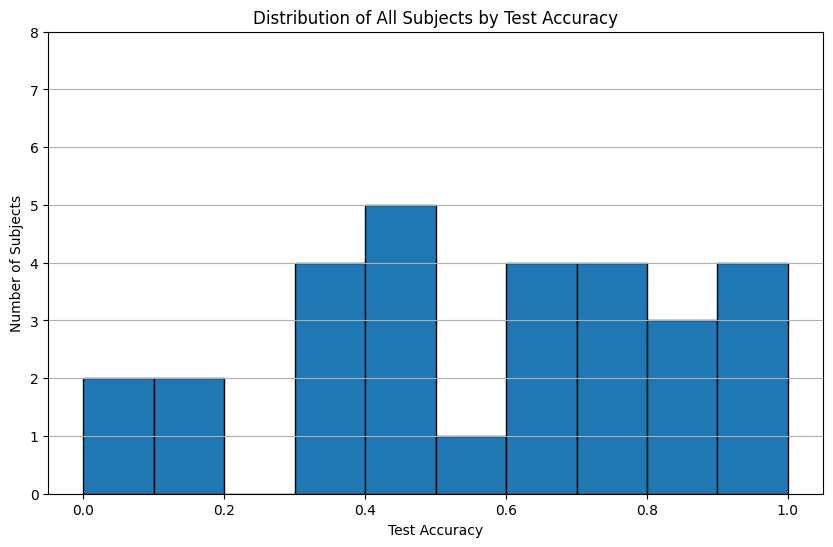

In [92]:
import matplotlib.pyplot as plt
import numpy as np
# Assuming alz_summary_df already exists
# (if not, generate it from your prediction correctness data)

# Sort the DataFrame (optional, not strictly needed for histogram)
total_summary = pd.concat([cntrl_summary_df_sorted, alz_summary_df_sorted])

# Plot
plt.figure(figsize=(10, 6))
plt.hist(cntrl_summary_df_sorted["Test Accuracy"], bins=np.linspace(0, 1, 11), edgecolor='black')
plt.title("Distribution of All Subjects by Test Accuracy")
plt.xlabel("Test Accuracy")
plt.ylabel("Number of Subjects")
plt.grid(axis='y')
plt.ylim(0,8)
plt.show()


In [93]:
# Add incorrect predictions to Alzheimer and Control summary
alz_summary_df["Incorrect"] = alz_summary_df["Total Epochs"] - alz_summary_df["Correct"]
cntrl_summary_df["Incorrect"] = cntrl_summary_df["Total Epochs"] - cntrl_summary_df["Correct"]

# Optional: combine them into one table
total_summary_df = pd.concat([alz_summary_df, cntrl_summary_df])

# Show a sample
print(total_summary_df[["SubjectID", "Group", "Correct", "Incorrect", "Total Epochs", "Test Accuracy"]].head())


  SubjectID        Group  Correct  Incorrect  Total Epochs  Test Accuracy
0   sub-001  Alzheimer's     1985          5          1990         0.9975
1   sub-002  Alzheimer's     1627       1007          2634         0.6177
2   sub-003  Alzheimer's      577        437          1014         0.5690
3   sub-004  Alzheimer's     2346          1          2347         0.9996
4   sub-005  Alzheimer's     2608         63          2671         0.9764


In [101]:
def summary_report_from_df(target_df, other_df, label_name="Gradient Boosting Classifier"):
    tp = target_df["Correct"].sum()       # True Positives
    fn = target_df["Incorrect"].sum()     # False Negatives
    fp = other_df["Incorrect"].sum()      # False Positives (wrong predictions for other class)

    support = tp + fn  # Total true samples for this class

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

    return {
        "label": label_name,
        "precision": precision,
        "recall": recall,
        "f1-score": f1,
        "support": support
    }

# Build both reports
alz_report = summary_report_from_df(alz_summary_df, cntrl_summary_df, "Alzheimer's")
cntrl_report = summary_report_from_df(cntrl_summary_df, alz_summary_df, "Control")

# Combine and display
group_reports = pd.DataFrame([cntrl_report, alz_report])
print(group_reports.set_index("label"))


             precision    recall  f1-score  support
label                                              
Control       0.722416  0.578956  0.642779    81165
Alzheimer's   0.699651  0.815119  0.752984    97663


In [102]:
def subject_level_summary_report(target_df, other_df, label_name):
    # Boolean mask: correctly classified subjects
    tp_mask = (target_df["Correct"] / target_df["Total Epochs"]) > 0.5
    fn_mask = ~tp_mask

    tp = tp_mask.sum()  # Correct subjects in this group
    fn = fn_mask.sum()  # Incorrect subjects in this group

    # Subjects from the OTHER group misclassified as this one
    fp_mask = (other_df["Correct"] / other_df["Total Epochs"]) <= 0.5
    fp = fp_mask.sum()

    support = tp + fn  # total subjects in the group

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

    return {
        "label": label_name,
        "precision": precision,
        "recall": recall,
        "f1-score": f1,
        "support (subjects)": support
    }

# Build both reports (subject-level)
alz_subj_report = subject_level_summary_report(alz_summary_df, cntrl_summary_df, "Alzheimer's")
cntrl_subj_report = subject_level_summary_report(cntrl_summary_df, alz_summary_df, "Control")

# Combine and display
subject_group_reports = pd.DataFrame([cntrl_subj_report, alz_subj_report])
print(subject_group_reports.set_index("label"))


             precision    recall  f1-score  support (subjects)
label                                                         
Control       0.800000  0.551724  0.653061                  29
Alzheimer's   0.711111  0.888889  0.790123                  36
